<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/Handwritten_Digit_Recognition_using_MNIST_Dataset_by_OMOKE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf

# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

print("MNIST dataset loaded successfully!")
print(f"Training images shape: {train_images.shape}")
print(f"Training labels shape: {train_labels.shape}")
print(f"Test images shape: {test_images.shape}")
print(f"Test labels shape: {test_labels.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST dataset loaded successfully!
Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)


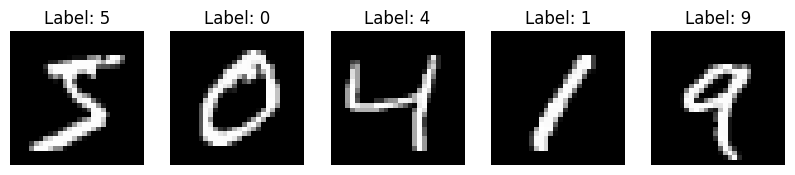

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 2))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f'Label: {train_labels[i]}')
    plt.axis('off')
plt.show()

In [ ]:
# Normalize pixel values to be between 0 and 1
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Reshape images to include a channel dimension (28, 28, 1)
train_images = train_images.reshape((-1, 28, 28, 1))
test_images = test_images.reshape((-1, 28, 28, 1))

print(f"Normalized training images shape: {train_images.shape}")
print(f"Normalized test images shape: {test_images.shape}")
print(f"New pixel value range: {train_images.min()} to {train_images.max()}")

Normalized training images shape: (60000, 28, 28, 1)
Normalized test images shape: (10000, 28, 28, 1)
New pixel value range: 0.0 to 1.0


In [ ]:
from tensorflow.keras import layers, models

# Design the neural network architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
history = model.fit(train_images, train_labels, epochs=5,
                    validation_data=(test_images, test_labels))

print("Training complete!")

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9524 - loss: 0.1610 - val_accuracy: 0.9792 - val_loss: 0.0671
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 39s 16ms/step - accuracy: 0.9825 - loss: 0.0583 - val_accuracy: 0.9822 - val_loss: 0.0552
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 17ms/step - accuracy: 0.9878 - loss: 0.0380 - val_accuracy: 0.9849 - val_loss: 0.0452
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9913 - loss: 0.0270 - val_accuracy: 0.9850 - val_loss: 0.0448
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9943 - loss: 0.0178 - val_accuracy: 0.9857 - val_loss: 0.0460
Training complete!


In [ ]:
# Evaluate the model on the test dataset
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

313/313 - 2s - 6ms/step - accuracy: 0.9857 - loss: 0.0460

Test accuracy: 0.9857
Test loss: 0.0460


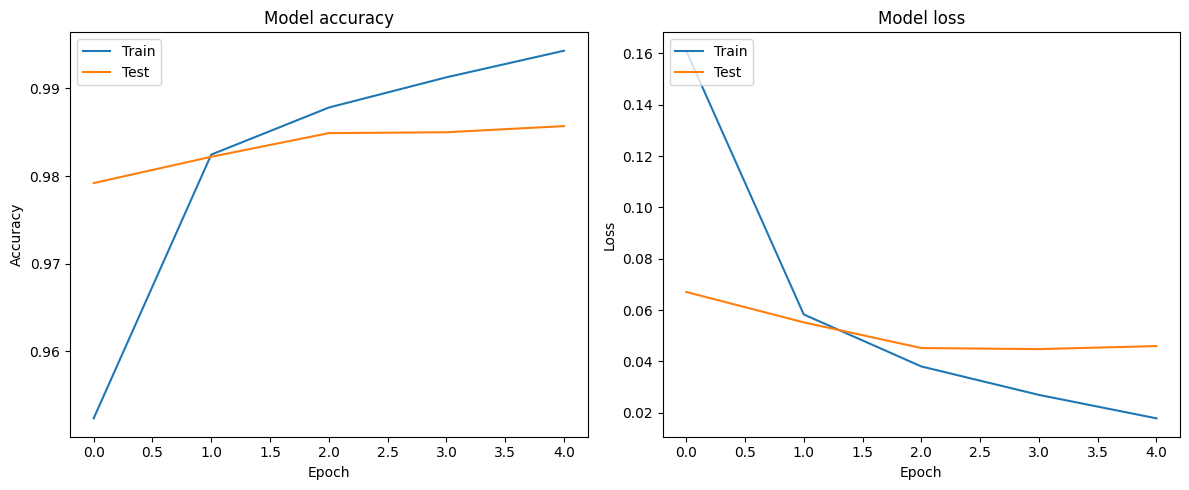

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))

# Ensure the 'history' object exists, which is generated by model.fit()
# If the model training cell was not executed, 'history' will not be defined.
if 'history' in globals():
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')

    # Plot training & validation loss values
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print("Error: The 'history' variable is not defined.")
    print("Please ensure the model training cell (cell id 7d9bbf97) was executed successfully before running this cell.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


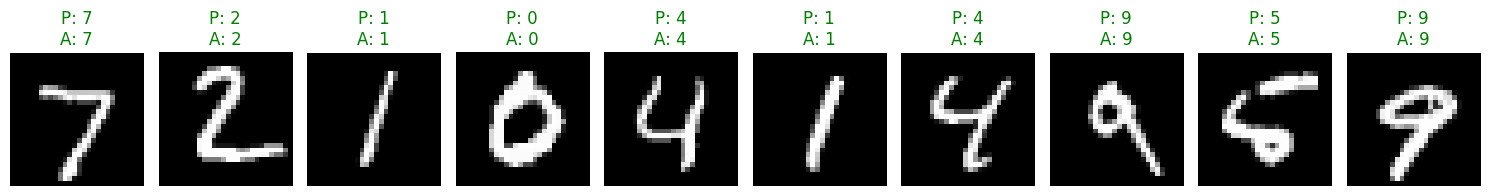

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Make predictions on the test set
predictions = model.predict(test_images)

# Visualize the first 10 test images and their predicted labels
plt.figure(figsize=(15, 3))
for i in range(10):
    plt.subplot(1, 10, i + 1)
    plt.imshow(test_images[i].reshape(28, 28), cmap='gray')

    predicted_label = np.argmax(predictions[i])
    actual_label = test_labels[i]

    color = 'green' if predicted_label == actual_label else 'red'
    plt.title(f"P: {predicted_label}\nA: {actual_label}", color=color)
    plt.axis('off')
plt.tight_layout()
plt.show()

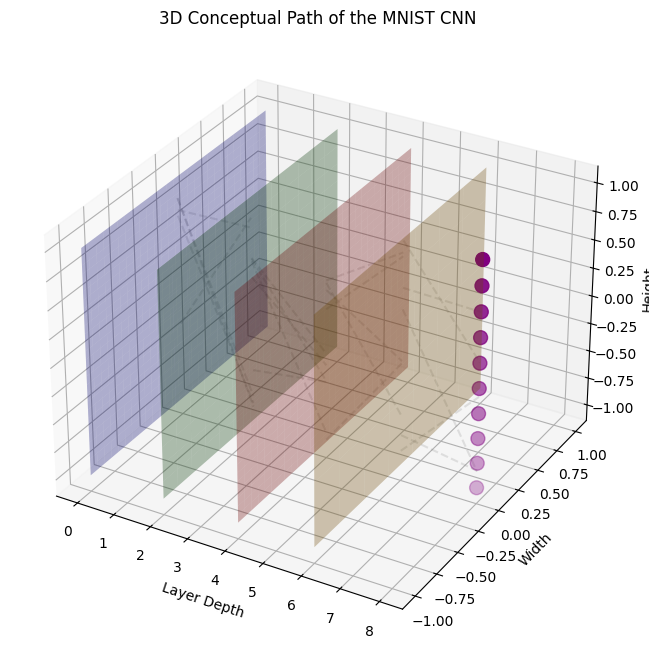

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

def draw_neural_net_3d(layer_dims):
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Define layer colors
    colors = ['blue', 'green', 'red', 'orange', 'purple']

    # Iterate through layers
    for i, dim in enumerate(layer_dims):
        # Create a grid for each layer
        n = int(np.sqrt(dim)) if dim > 10 else dim
        if dim > 10:
            x, y = np.meshgrid(np.linspace(-1, 1, n), np.linspace(-1, 1, n))
            z = np.full_like(x, i * 2)
            ax.plot_surface(z, x, y, color=colors[i % len(colors)], alpha=0.3)
        else:
            # For smaller layers (like output), plot individual neurons
            z = np.full(dim, i * 2)
            x = np.zeros(dim)
            y = np.linspace(-1, 1, dim)
            ax.scatter(z, x, y, color=colors[i % len(colors)], s=100)

        # Draw 'paths' (lines) between layers
        if i > 0:
            prev_dim = layer_dims[i-1]
            # To keep it clean, we only draw a subset of paths
            num_paths = 5
            for _ in range(num_paths):
                idx_prev = np.random.randint(0, prev_dim)
                idx_curr = np.random.randint(0, dim)
                ax.plot([ (i-1)*2, i*2 ], [0, 0], [np.random.uniform(-1,1), np.random.uniform(-1,1)],
                        'gray', alpha=0.2, linestyle='--')

    ax.set_xlabel('Layer Depth')
    ax.set_ylabel('Width')
    ax.set_zlabel('Height')
    ax.set_title('3D Conceptual Path of the MNIST CNN')
    plt.show()

# Dimensions matching our model: Conv2D(approx), MaxPool(approx), Flatten(784), Dense(64), Dense(10)
layer_dimensions = [784, 196, 784, 64, 10]
draw_neural_net_3d(layer_dimensions)

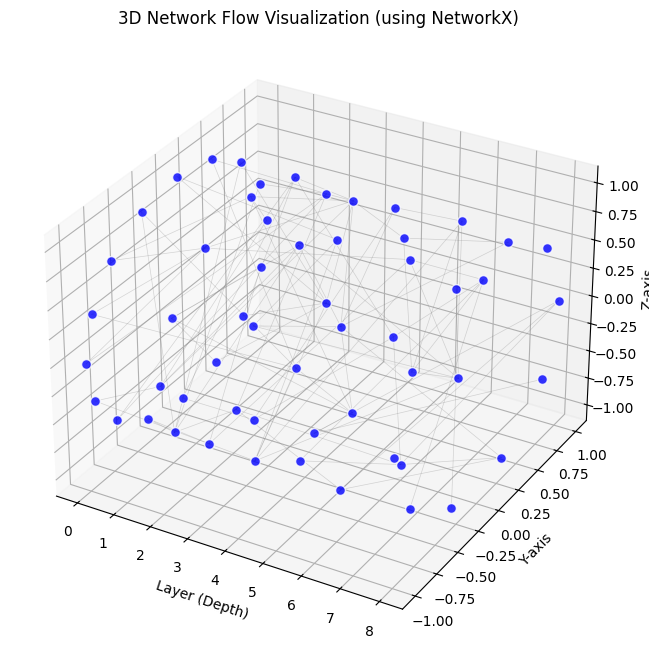

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def draw_3d_network_nx(layer_dims):
    G = nx.Graph()
    pos = {}

    # Create nodes and positions
    for l, dim in enumerate(layer_dims):
        # For large layers, we only sample nodes to keep the visualization readable
        nodes_to_draw = min(dim, 20)
        for i in range(nodes_to_draw):
            node_id = f"l{l}_n{i}"
            G.add_node(node_id)
            # Position: x=layer index, y=horizontal spread, z=vertical spread
            # Using a circular layout for each layer in the Y-Z plane
            angle = 2 * np.pi * i / nodes_to_draw
            pos[node_id] = (l * 2, np.cos(angle), np.sin(angle))

    # Create edges between adjacent layers (sampled for clarity)
    layers = list(range(len(layer_dims)))
    for l1, l2 in zip(layers[:-1], layers[1:]):
        nodes1 = [n for n in G.nodes if n.startswith(f"l{l1}_")]
        nodes2 = [n for n in G.nodes if n.startswith(f"l{l2}_")]
        for n1 in nodes1:
            # Connect each node in layer i to 2 random nodes in layer i+1
            targets = np.random.choice(nodes2, size=2, replace=False)
            for n2 in targets:
                G.add_edge(n1, n2)

    # Plotting
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Extract node coordinates
    for node, (x, y, z) in pos.items():
        ax.scatter(x, y, z, c='blue', s=50, edgecolors='white', alpha=0.8)

    # Extract edge coordinates
    for edge in G.edges():
        x_coords = [pos[edge[0]][0], pos[edge[1]][0]]
        y_coords = [pos[edge[0]][1], pos[edge[1]][1]]
        z_coords = [pos[edge[0]][2], pos[edge[1]][2]]
        ax.plot(x_coords, y_coords, z_coords, color='gray', alpha=0.3, linewidth=0.5)

    ax.set_title("3D Network Flow Visualization (using NetworkX)")
    ax.set_xlabel("Layer (Depth)")
    ax.set_ylabel("Y-axis")
    ax.set_zlabel("Z-axis")
    plt.show()

# Visualize the model architecture: Input(28x28), Conv/Pool, Flatten, Dense, Output
draw_3d_network_nx([16, 12, 10, 8, 10])

In [ ]:
import plotly.graph_objects as go
import numpy as np

def draw_interactive_3d_flow(layer_dims, layer_names):
    fig = go.Figure()

    # Iterate through layers to create nodes
    for l, dim in enumerate(layer_dims):
        nodes_to_draw = min(dim, 40)
        grid_size = int(np.ceil(np.sqrt(nodes_to_draw)))

        x = np.full(nodes_to_draw, l * 3)
        y = [(i % grid_size) - (grid_size / 2) for i in range(nodes_to_draw)]
        z = [(i // grid_size) - (grid_size / 2) for i in range(nodes_to_draw)]

        # Add nodes for this layer
        fig.add_trace(go.Scatter3d(
            x=x, y=y, z=z,
            mode='markers',
            marker=dict(size=5, opacity=0.8),
            name=layer_names[l],
            hoverinfo='text',
            text=f"Layer: {layer_names[l]}<br>Nodes: {dim}"
        ))

        # Add connection lines (edges) to the next layer
        if l < len(layer_dims) - 1:
            next_nodes_to_draw = min(layer_dims[l+1], 40)
            next_grid_size = int(np.ceil(np.sqrt(next_nodes_to_draw)))

            for i in range(nodes_to_draw):
                # Connect to a random node in the next layer
                target_idx = np.random.randint(0, next_nodes_to_draw)

                x_line = [l * 3, (l + 1) * 3]
                y_line = [y[i], (target_idx % next_grid_size) - (next_grid_size / 2)]
                z_line = [z[i], (target_idx // next_grid_size) - (next_grid_size / 2)]

                fig.add_trace(go.Scatter3d(
                    x=x_line, y=y_line, z=z_line,
                    mode='lines',
                    line=dict(color='gray', width=1),
                    opacity=0.2,
                    showlegend=False,
                    hoverinfo='none'
                ))

    fig.update_layout(
        title="Interactive 3D Neural Flow (Drag to Rotate)",
        scene=dict(
            xaxis_title='Layer Depth',
            yaxis_title='Width',
            zaxis_title='Height',
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            zaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )
    fig.show()

mnist_dims = [784, 128, 64, 64, 10]
mnist_labels = ["Input", "Conv/Pool", "Flatten", "Dense", "Output"]
draw_interactive_3d_flow(mnist_dims, mnist_labels)

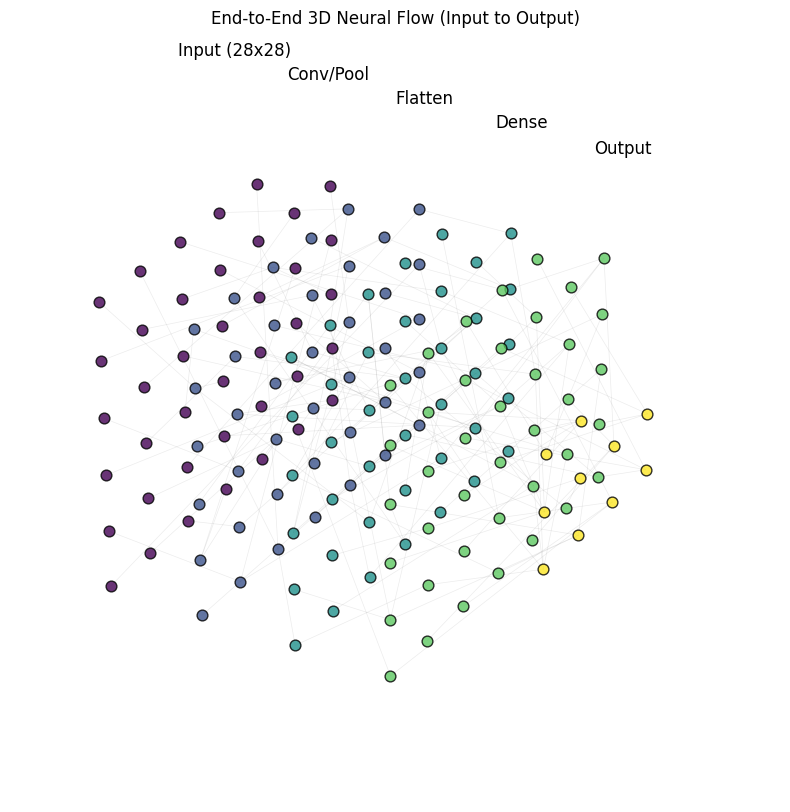

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

def draw_full_3d_flow(layer_dims, layer_names):
    G = nx.Graph()
    pos = {}

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    colors = plt.cm.viridis(np.linspace(0, 1, len(layer_dims)))

    for l, dim in enumerate(layer_dims):
        # For very large layers, we cap at 40 nodes for visualization clarity
        nodes_to_draw = min(dim, 40)
        for i in range(nodes_to_draw):
            node_id = f"l{l}_n{i}"
            G.add_node(node_id)

            # Arrange nodes in a 2D grid within the Y-Z plane at each X depth
            grid_size = int(np.ceil(np.sqrt(nodes_to_draw)))
            y = (i % grid_size) - (grid_size / 2)
            z = (i // grid_size) - (grid_size / 2)
            pos[node_id] = (l * 3, y, z)

            ax.scatter(l * 3, y, z, color=colors[l], s=60, edgecolors='k', alpha=0.8)

        ax.text(l * 3, 0, max(layer_dims)**0.1 + 2, layer_names[l], color='black', fontsize=12, ha='center')

    # Draw edges between layers
    for l in range(len(layer_dims) - 1):
        nodes_curr = [n for n in G.nodes if n.startswith(f"l{l}_")]
        nodes_next = [n for n in G.nodes if n.startswith(f"l{l+1}_")]

        for n1 in nodes_curr:
            # Connect to 1-2 random nodes in the next layer to represent flow
            targets = np.random.choice(nodes_next, size=min(len(nodes_next), 1), replace=False)
            for n2 in targets:
                x_coords = [pos[n1][0], pos[n2][0]]
                y_coords = [pos[n1][1], pos[n2][1]]
                z_coords = [pos[n1][2], pos[n2][2]]
                ax.plot(x_coords, y_coords, z_coords, color='gray', alpha=0.15, linewidth=0.5)

    ax.set_title("End-to-End 3D Neural Flow (Input to Output)")
    ax.set_axis_off()
    plt.show()

# Defining the layers of our CNN: Input, Conv2D, MaxPool, Flatten, Dense, Output
mnist_dims = [784, 128, 64, 64, 10]
mnist_labels = ["Input (28x28)", "Conv/Pool", "Flatten", "Dense", "Output"]
draw_full_3d_flow(mnist_dims, mnist_labels)

In [ ]:
import plotly.graph_objects as go
import numpy as np

def create_physics_flow_animation(layer_dims, layer_names):
    # Parameters
    num_particles = 30
    num_frames = 50
    layer_spacing = 3

    # Pre-calculate node positions for each layer
    layer_positions = []
    for l, dim in enumerate(layer_dims):
        nodes_to_draw = min(dim, 20)
        grid_size = int(np.ceil(np.sqrt(nodes_to_draw)))
        x = np.full(nodes_to_draw, l * layer_spacing)
        y = [(i % grid_size) - (grid_size / 2) for i in range(nodes_to_draw)]
        z = [(i // grid_size) - (grid_size / 2) for i in range(nodes_to_draw)]
        layer_positions.append(np.column_stack((x, y, z)))

    # Create particles with initial positions at Layer 0
    # Initial state: Particle at random node in layer 0
    particle_start_nodes = np.random.randint(0, len(layer_positions[0]), size=num_particles)
    particle_pos = layer_positions[0][particle_start_nodes].astype(float)

    # Assign random target nodes in the next layer for each particle
    particle_targets = np.random.randint(0, len(layer_positions[1]), size=num_particles)

    frames = []
    for f in range(num_frames):
        # Physics: Move particles linearly toward their targets in the next layer
        # Each full layer transition happens every N frames
        # For simplicity, we animate one global 'pulse' through the network

        current_layer_idx = int((f / num_frames) * (len(layer_dims) - 1))
        next_layer_idx = min(current_layer_idx + 1, len(layer_dims) - 1)

        # Progress within the current layer transition (0 to 1)
        t = (f / num_frames * (len(layer_dims) - 1)) % 1.0

        # Calculate current positions based on linear interpolation (constant velocity)
        # For each frame, we pick a start and end point in the current segment
        starts = layer_positions[current_layer_idx][np.random.randint(0, len(layer_positions[current_layer_idx]), size=num_particles)]
        ends = layer_positions[next_layer_idx][np.random.randint(0, len(layer_positions[next_layer_idx]), size=num_particles)]

        current_x = starts[:, 0] + t * (ends[:, 0] - starts[:, 0])
        current_y = starts[:, 1] + t * (ends[:, 1] - starts[:, 1])
        current_z = starts[:, 2] + t * (ends[:, 2] - starts[:, 2])

        frames.append(go.Frame(data=[go.Scatter3d(x=current_x, y=current_y, z=current_z, mode='markers', marker=dict(color='red', size=4))]))

    # Static background: The layer nodes
    fig = go.Figure(
        data=[go.Scatter3d(x=[], y=[], z=[], mode='markers', marker=dict(color='blue', size=2, opacity=0.3))],
        layout=go.Layout(
            title="Physics-based Data Flow Animation",
            updatemenus=[dict(type="buttons", buttons=[dict(label="Play", method="animate", args=[None, {"frame": {"duration": 50, "redraw": True}}])])],
            scene=dict(
                xaxis=dict(range=[-1, 15], title='Layer Depth'),
                yaxis=dict(range=[-5, 5]),
                zaxis=dict(range=[-5, 5])
            ),
            showlegend=True
        ),
        frames=frames
    )

    # Add the static layers for context
    for l, pos in enumerate(layer_positions):
        fig.add_trace(go.Scatter3d(x=pos[:, 0], y=pos[:, 1], z=pos[:, 2], mode='markers', name=layer_names[l], marker=dict(size=4, opacity=0.5)))

    fig.show()

mnist_dims = [784, 128, 64, 64, 10]
mnist_labels = ["Input", "Conv/Pool", "Flatten", "Dense", "Output"]
create_physics_flow_animation(mnist_dims, mnist_labels)